In [2]:
import pandas as pd
import matplotlib.pyplot as plt
#loading_data_frames
cr=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\constructor_results.csv")
d=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\drivers.csv")
r=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\races.csv")
result=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\results.csv")
c=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\circuits.csv")
quali=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\qualifying.csv")
const=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\constructors.csv")
ds=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\driver_standings.csv")
cs=pd.read_csv("C:\\Users\\honey\\OneDrive\\Desktop\\f1 analysis\\constructor_standings.csv")


In [64]:
#dropping_unnecesarry_columns
cr=cr.drop(columns=['status'])
d=d.drop(columns=['url'])
r=r.drop(columns=['url','fp1_date','fp1_time','fp2_time','fp2_date','fp3_time','fp3_date','quali_date','quali_time','sprint_date','sprint_time','date'])
c=c.drop(columns=['url'])

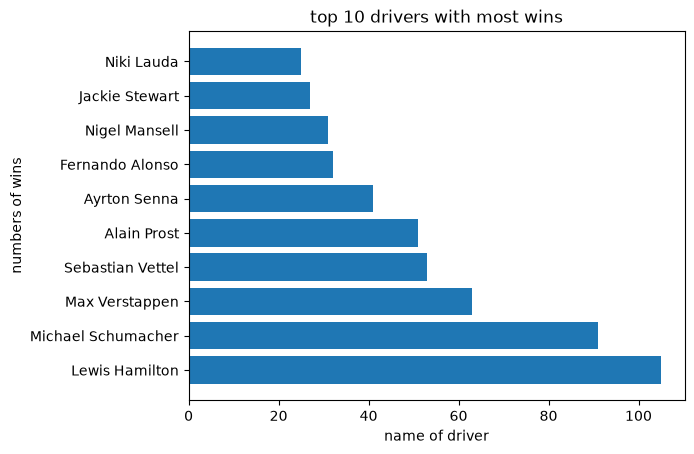

In [ ]:
#finding_who_won_the_most_races
newdata=pd.merge(d,result,on='driverId')
winner=newdata[newdata['positionOrder']==1]
winner['fullname']=winner['forename']+" "+winner['surname']
mw=winner.groupby(['fullname']).size().reset_index(name='wins').sort_values(by='wins',ascending=False).head(10)
rwg=plt.barh(mw['fullname'],mw['wins'])
rwg=plt.title('top 10 drivers with most wins')
rwg=plt.xlabel('name of driver')
rwg=plt.ylabel('numbers of wins')

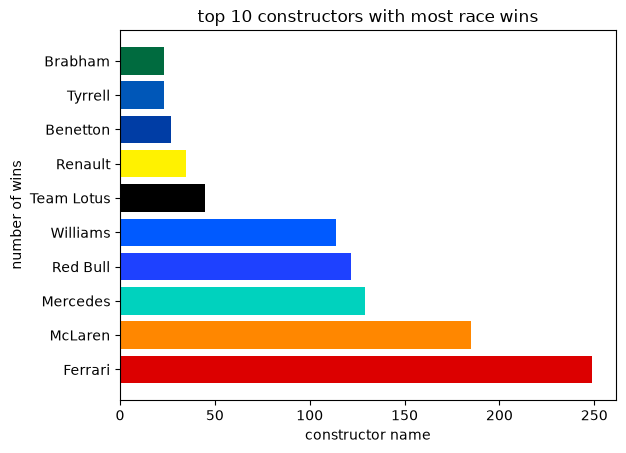

In [ ]:
#finding_which_constructor_won_most_races
nd=pd.merge(result,const,on='constructorId')
nd=nd[nd['position']=='1']
mwc=nd.groupby(['constructorId','name']).size().reset_index(name='wins')
mwc=mwc.sort_values(by='wins',ascending=False).head(10)
mrwc=plt.barh(mwc['name'],mwc['wins'],color=['#DC0000','#FF8700','#00D2BE','#1e41ff','#005AFF','#000000','#FFF200','#003DA5','#0057B8','#006B3F'])
mrwc=plt.title('top 10 constructors with most race wins')
mrwc=plt.xlabel('constructor name')
mrwc=plt.ylabel('number of wins')

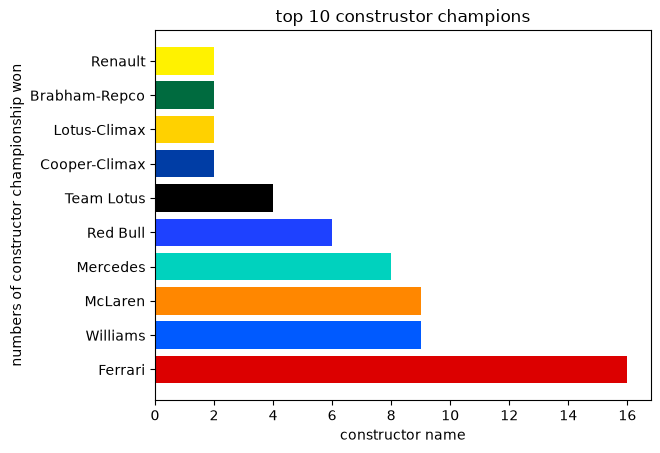

In [6]:
#constructors_with_most_championships
ch=pd.merge(cs,r,on='raceId')
cha=pd.merge(ch,const,on='constructorId')
max_round=ch.groupby(['year'])['round'].max()
champ=pd.merge(cha,max_round,on='year')
#champ
df=champ[champ['round_x']==champ['round_y']]
champions=df[df['position']==1].groupby(['name_y']).size().reset_index(name='number of championship won')
champions=champions.sort_values(by='number of championship won',ascending=False).head(10)
ccg=plt.barh(champions['name_y'],champions['number of championship won'],color=['#DC0000','#005AFF','#FF8700','#00D2BE','#1e41ff','#000000','#003da5','#ffd100','#006B3F','#FFF200'])
ccg=plt.title('top 10 construstor champions')
ccg=plt.xlabel('constructor name')
ccg=plt.ylabel('numbers of constructor championship won')

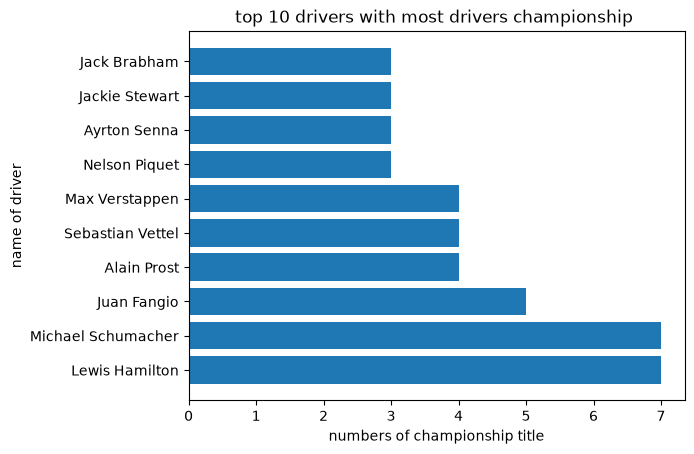

In [123]:
#driver with most championships
dc=pd.merge(r,ds,on='raceId')
dcha=pd.merge(dc,d,on='driverId')
mr=dcha.groupby(['year'])['round'].max()
dchamp=pd.merge(mr,dcha,on='year')
dchamp=dchamp[dchamp['round_x']==dchamp['round_y']]
dchamp['fullname']=dchamp['forename']+" "+dchamp['surname']
dchamp=dchamp[dchamp['position']==1].groupby(['fullname']).size().reset_index(name='championship won').sort_values(by='championship won',ascending=False).head(10)
dcg=plt.barh(dchamp['fullname'],dchamp['championship won'])
dcg=plt.title('top 10 drivers with most drivers championship ')
dcg=plt.xlabel('numbers of championship title')
dcg=plt.ylabel('name of driver')

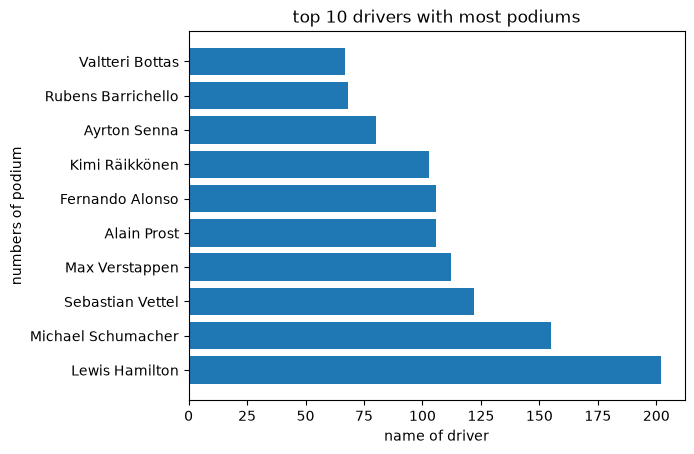

In [93]:
#drivers with most podium finishes
pod=pd.merge(d,result,on='driverId')
pod=pod[pod['positionOrder']<=3]
pod['fullname']=pod['forename']+" "+pod['surname']
pod=pod.groupby(['fullname']).agg({'fullname':'count'}).rename(columns={'fullname':'numbers_of_podiums'}).sort_values(by='numbers_of_podiums',ascending=False).head(10)
pod=pod.reset_index()
pdg=plt.barh(pod['fullname'],pod['numbers_of_podiums'])
pdg=plt.title('top 10 drivers with most podiums')
pdg=plt.xlabel('name of driver')
pdg=plt.ylabel('numbers of podium')

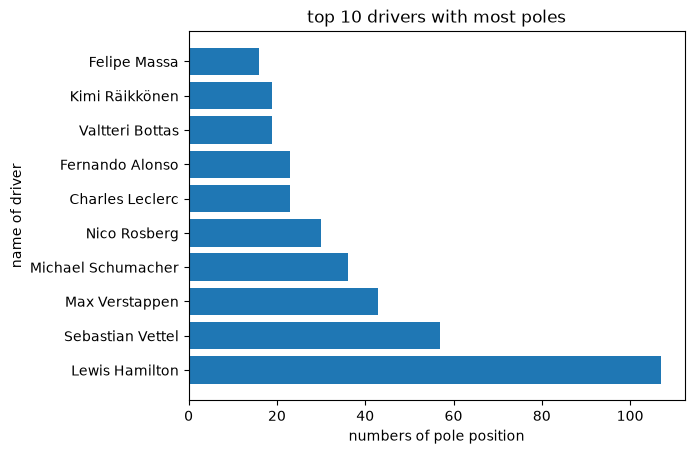

In [91]:
#driver with most poles
poles=pd.merge(d,quali,on='driverId')
poles=poles[poles['position']==1]
poles['fullname']=poles['forename']+" "+poles['surname']
poles=poles.groupby(['fullname']).agg({'fullname':'count'}).rename(columns={'fullname':'most poles'}).sort_values(by='most poles',ascending=False).head(10)
poles=poles.reset_index()
pg=plt.barh(poles['fullname'],poles['most poles'])
pg=plt.title('top 10 drivers with most poles')
pg=plt.xlabel('numbers of pole position')
pg=plt.ylabel('name of driver')

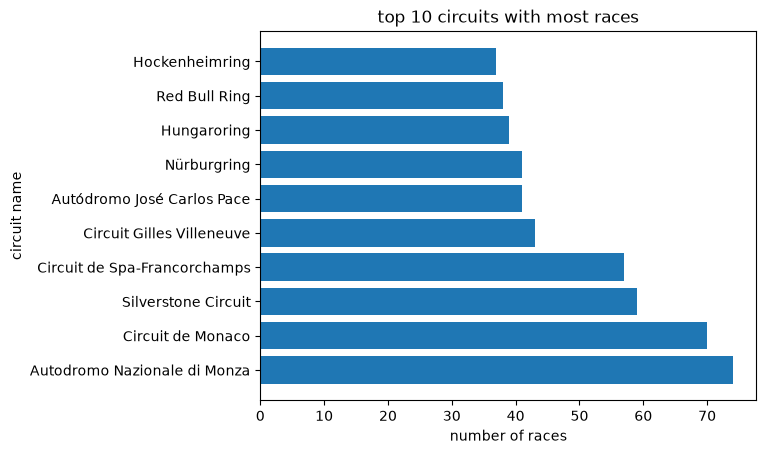

In [89]:
#most raced circuits
mostrace=pd.merge(r,c,on='circuitId')
#mostrace.head(10)
mostrace=mostrace.groupby(['name_y']).agg({'name_y':'count'}).rename(columns={'name_y':'numbers of races'}).sort_values(by='numbers of races',ascending=False).head(10)
mostrace=mostrace.reset_index()
mrcircuit=plt.barh(mostrace['name_y'],mostrace['numbers of races'])
mrcircuit=plt.title('top 10 circuits with most races')
mrcircuit=plt.xlabel('number of races')
mrcircuit=plt.ylabel('circuit name')



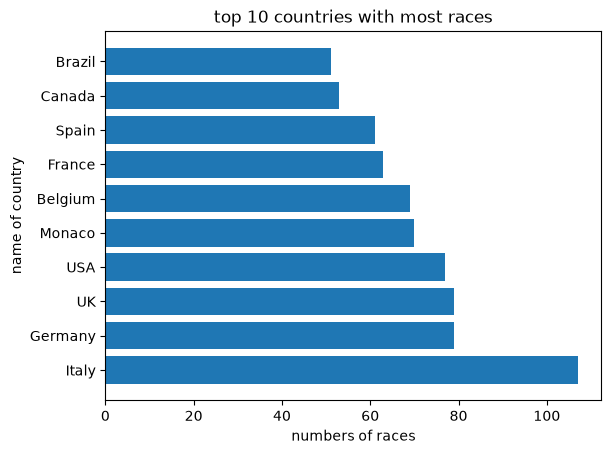

In [82]:
#country which hosted most races
cmost=pd.merge(c,r,on='circuitId')
cmost=cmost.groupby(['country']).agg({'country':'count'}).rename(columns={'country':'races hosted'}).sort_values(by='races hosted',ascending=False).head(10)
cmost=cmost.reset_index()
mrc=plt.barh(cmost['country'],cmost['races hosted'])
mrc=plt.title('top 10 countries with most races')
mec=plt.xlabel('numbers of races')
mrc=plt.ylabel('name of country')

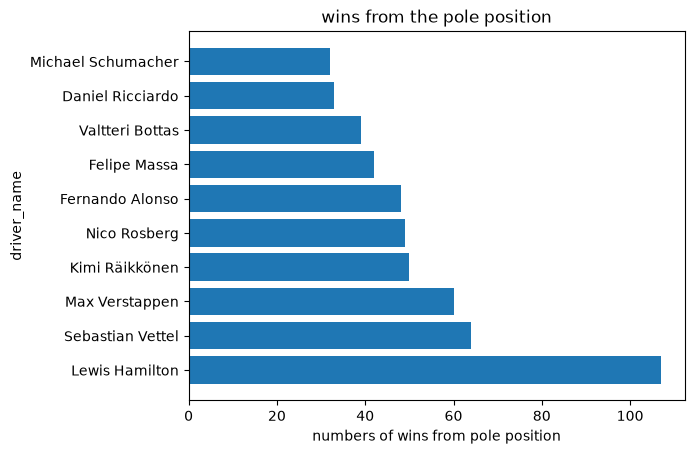

In [73]:
#pole vs rcae win
pw=pd.merge(result,quali,on=['driverId','raceId'])
pvw=pd.merge(d,pw,on=['driverId'])
pvw['fullname']=pvw['forename']+" "+pvw['surname']
pvw=pvw[pvw['positionOrder']==pvw['position_y']]
polevw=pvw.groupby(['fullname']).agg({'position_y':'count'}).rename(columns={'position_y': 'win from pole position'}).sort_values(by='win from pole position',ascending=False)
polevw=polevw.head(10)
polevw=polevw.reset_index()
poler=plt.barh(polevw['fullname'],polevw['win from pole position'])
poler=plt.title('wins from the pole position')
ploler=plt.xlabel('numbers of wins from pole position')
poler=plt.ylabel('driver_name')

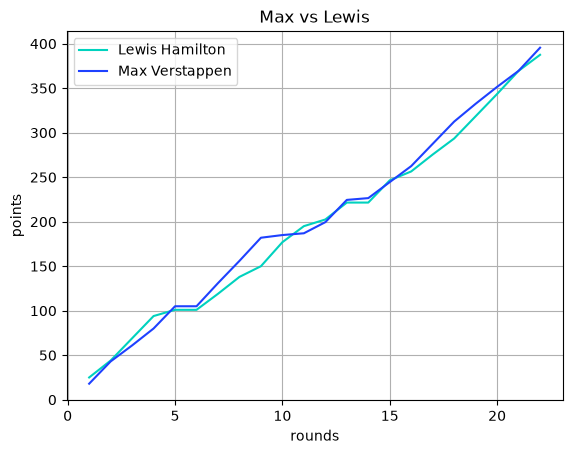

In [7]:
#max vs lewis season 2021
ml=pd.merge(r,result,on='raceId')
ml=ml[ml['year']==2021]
ml=pd.merge(ml,ds,on=['raceId','driverId'])
lm=pd.merge(ml,d,on='driverId')
lm['fullname']=lm['forename']+" "+lm['surname']
lm=lm[lm['fullname'].isin(['Lewis Hamilton','Max Verstappen'])]
lm=lm.rename(columns={'points_y':'points'})
lm=lm[['fullname','round','points']]
lewis=lm[lm['fullname']=='Lewis Hamilton']
Max=lm[lm['fullname']=='Max Verstappen']
lewis=lewis.sort_values(by='round',ascending=False)
Max=Max.sort_values(by='round',ascending=False)
mvl=plt.plot(lewis['round'],lewis['points'],label='Lewis Hamilton',color='#00D2BE')
mvl=plt.plot(Max['round'],Max['points'],label='Max Verstappen',color='#1e41ff')
mvl=plt.title('Max vs Lewis')
mvl=plt.xlabel('rounds')
mvl=plt.ylabel('points')
mvl=plt.legend()
mvl=plt.grid(True)